In [24]:
import os
import sys

paths = [
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/myopacus",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/torchdp",
    "/your/path/rpdp_fl/experiments",
]

for p in paths:
    if p not in sys.path:
        sys.path.append(p)

# Optional: also update environment variable
os.environ["PYTHONPATH"] = ":".join(sys.path)

In [ ]:
from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "cifar10"  

all_results = []

data_types = [
    "iid_10",
    "niid_dir_5",
    "niid_10_5",
    "niid_dir_1",
    "niid_10_2",
]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_rpdp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


Loading: ./fed_cifar10/iid_10/ditto/iid_10_results_ditto_rpdp_cifar10.csv
Loading: ./fed_cifar10/niid_dir_5/ditto/niid_dir_5_results_ditto_rpdp_cifar10.csv
Loading: ./fed_cifar10/niid_10_5/ditto/niid_10_5_results_ditto_rpdp_cifar10.csv
Loading: ./fed_cifar10/niid_dir_1/ditto/niid_dir_1_results_ditto_rpdp_cifar10.csv
Loading: ./fed_cifar10/niid_10_2/ditto/niid_10_2_results_ditto_rpdp_cifar10.csv


FileNotFoundError: [Errno 2] No such file or directory: './fed_cifar10/niid_10_2/ditto/niid_10_2_results_ditto_rpdp_cifar10.csv'

This graphs plots comparing Vanilla, Ditto w Global DP, and Ditto w Local DP
for one value of lambda and num_personal_steps

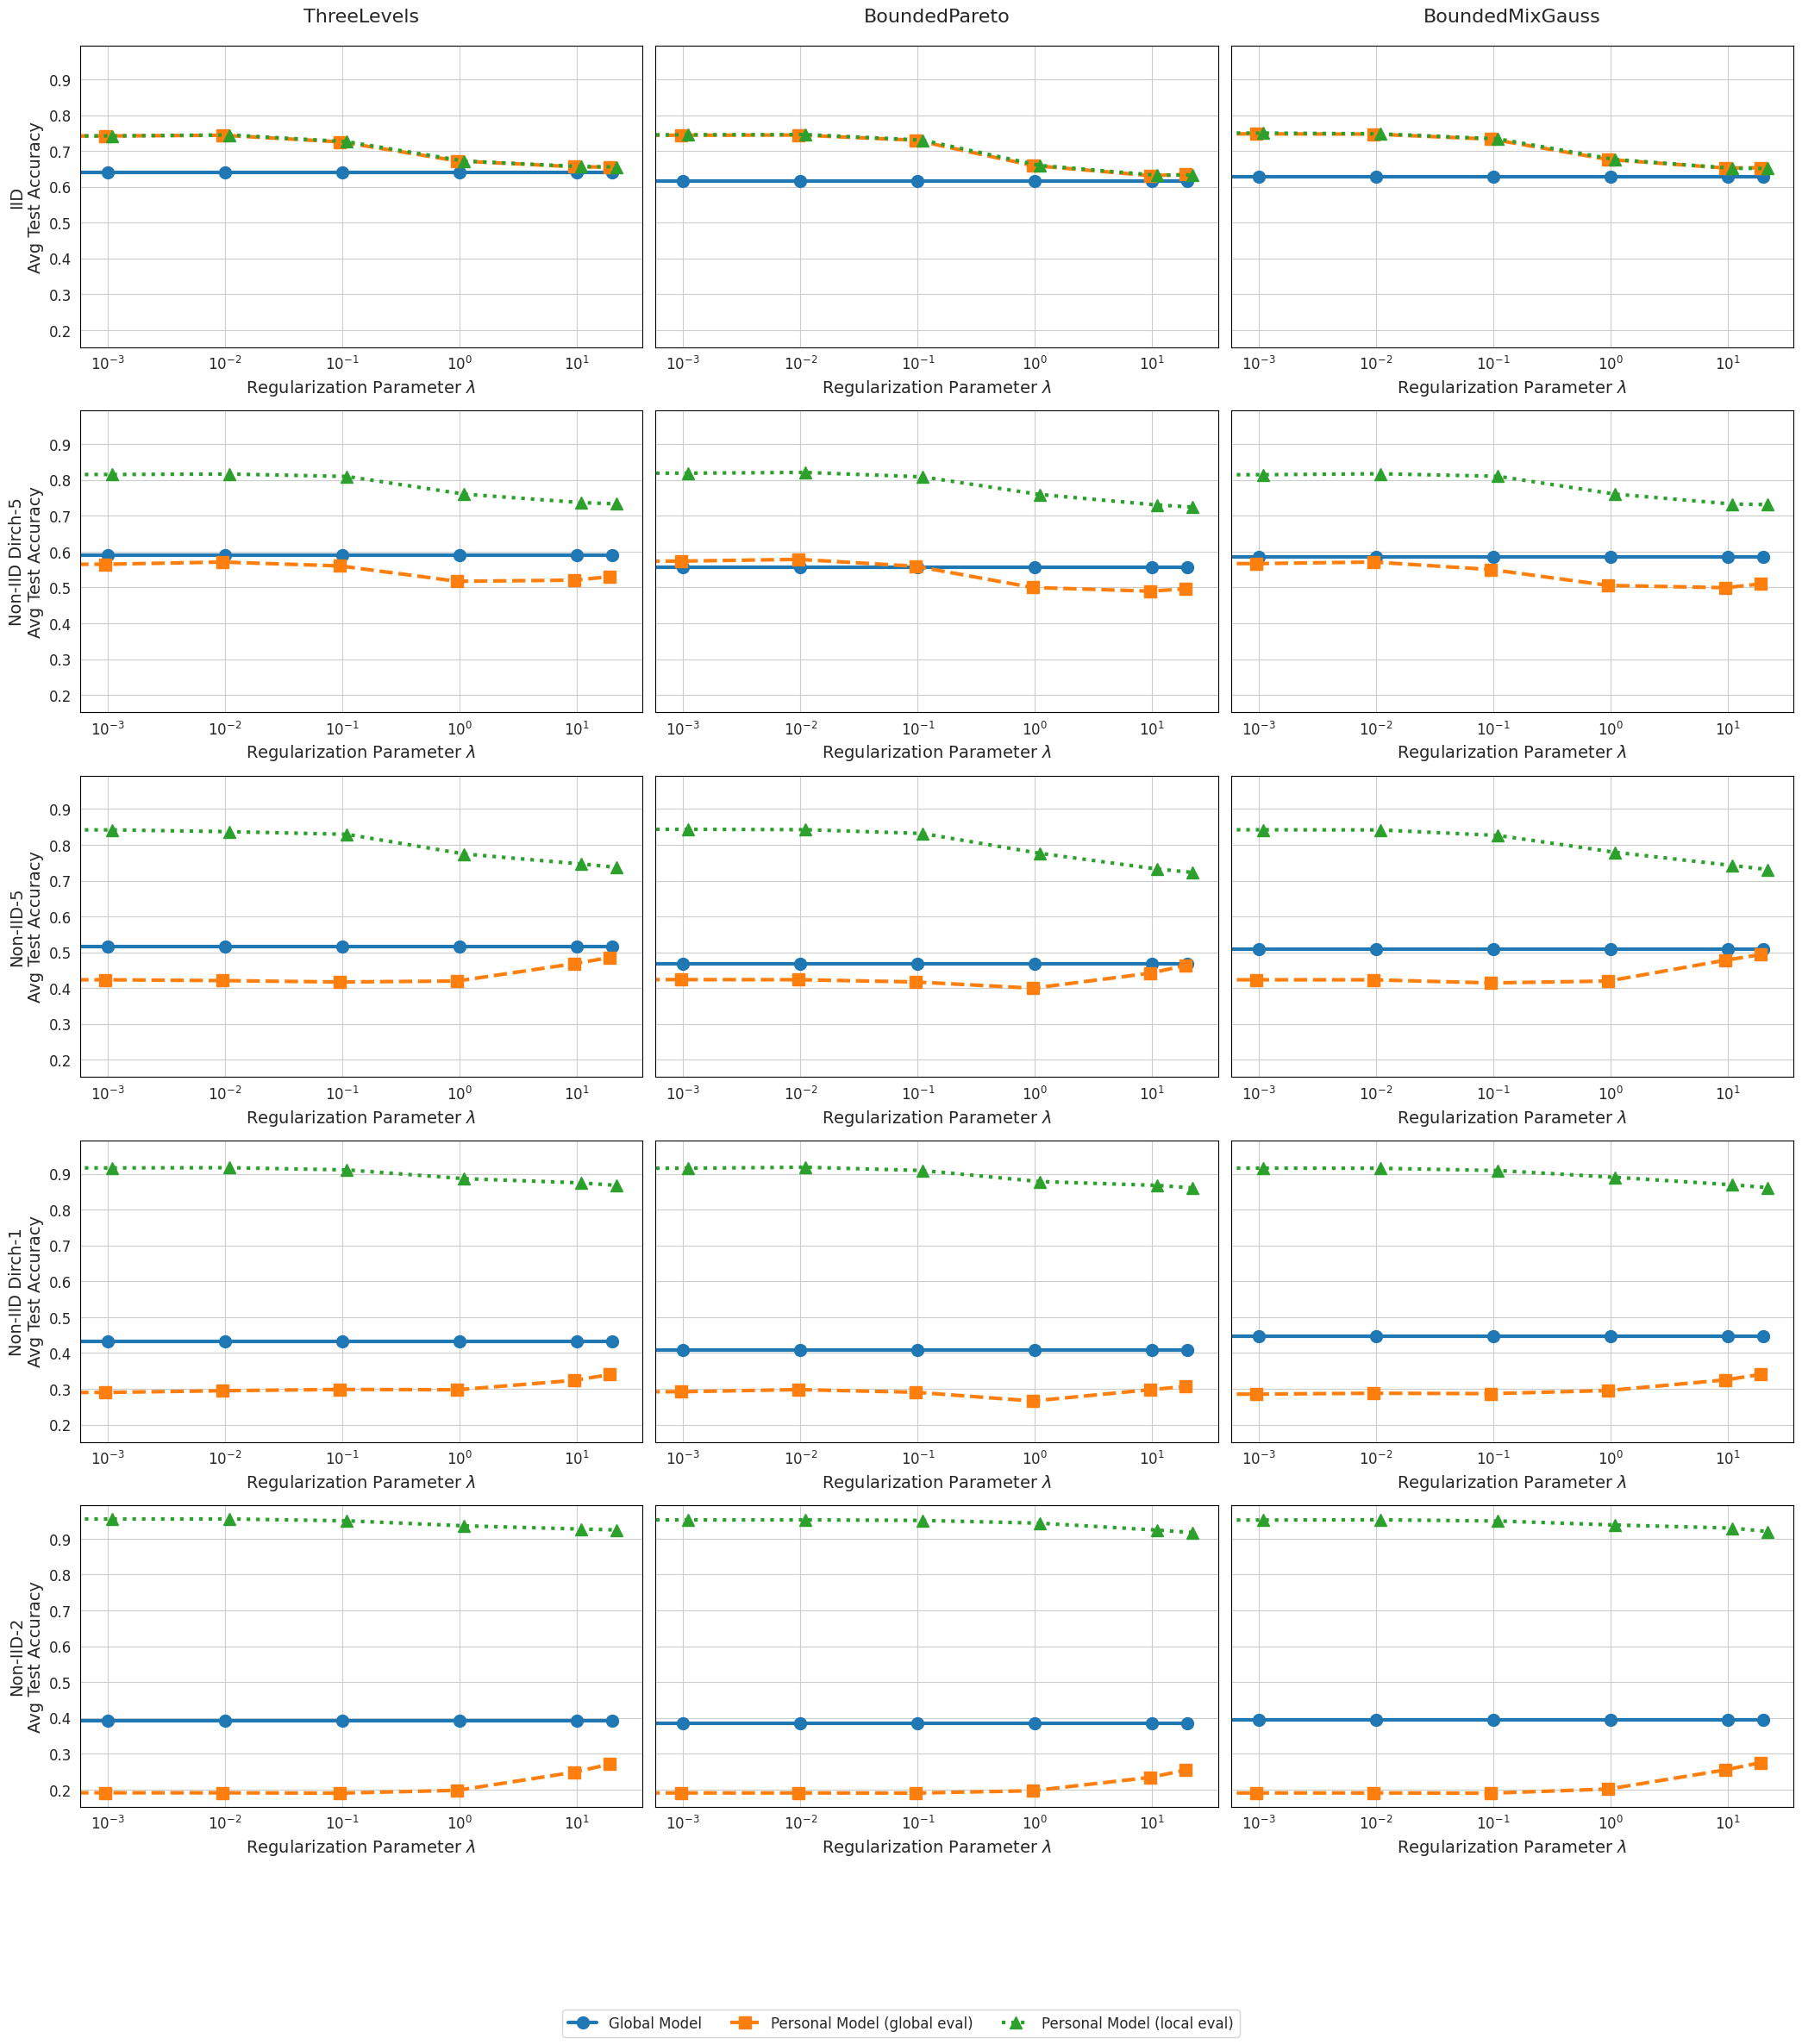

In [20]:
n_rows = len(datasets)
n_cols = len(distributions)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows), sharey=True)

# handle 1D arrays if only 1 row or 1 column
if n_rows == 1:
    axs = np.expand_dims(axs, axis=0)
if n_cols == 1:
    axs = np.expand_dims(axs, axis=1)

for r, (df_dataset, dataset_key) in enumerate(zip(all_results, datasets)):
    # make a copy to avoid modifying original
    df_dataset = df_dataset.copy()
    
    # make sure 'type' and 'lambda' are correct type
    df_dataset['type'] = df_dataset['type'].str.strip()
    df_dataset['lambda'] = df_dataset['lambda'].astype(float)
    df_dataset['e'] = df_dataset['e'].astype(str)
    
    # ADD 'dist' COLUMN
    df_dataset['dist'] = df_dataset['e'].apply(lambda x: x.split('-')[0])
    
    # filter for num_personal_steps
    df_dataset = df_dataset[df_dataset['num_personal_steps'] == num_steps]

    for c, dist in enumerate(distributions):
        ax = axs[r, c]
        df_dist = df_dataset[df_dataset['dist'] == dist]

        for method in methods:
            df_m = df_dist[df_dist['type'] == method]

            if df_m.empty:
                continue

            df_m = df_m.sort_values(by='lambda')
            x = df_m['lambda'].values * offset_map[method]

            ax.plot(
                x,
                df_m['mean_perf'],
                label=method_labels[method],
                linestyle=linestyle_map[method],
                marker=marker_map[method],
                color=colors[method],
                linewidth=3,
                markersize=10
            )

        ax.set_xscale('log')
        ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=14)
        ax.grid(True)
        ax.tick_params(axis='both', labelsize=12)

        # Only top row gets the distribution title
        if r == 0:
            ax.set_title(f"{dist}", fontsize=16, pad=20)

# set dataset names on the left side
for r, dataset_key in enumerate(datasets):
    axs[r, 0].set_ylabel(f"{dataset_names[dataset_key]}\nAvg Test Accuracy", fontsize=14)

# shared legend from first subplot that has lines
handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=12, ncol=len(methods))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [22]:

from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "heart_disease"   # change to "fashion_mnist" when needed

all_results = []

data_types= ["niid_10_5"]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_rpdp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


Loading: ./fed_heart_disease/niid_10_5/ditto/niid_10_5_results_ditto_rpdp_heart_disease.csv


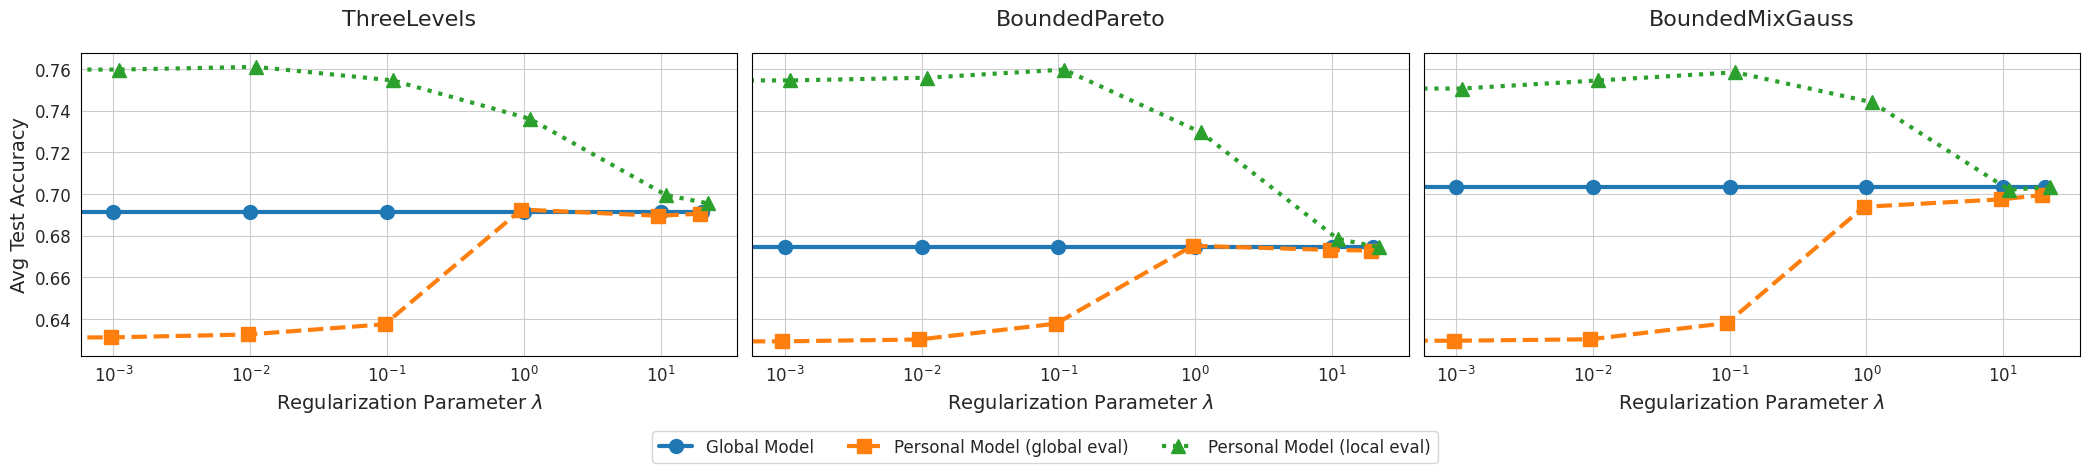

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor': 'black'})

methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Personal Model (global eval)',
    'personal': 'Personal Model (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.96,
    'personal': 1.10
}

num_steps = 15

# =========================
# DISTRIBUTIONS TO PLOT
# =========================
distributions = ['ThreeLevels', 'BoundedPareto', 'BoundedMixGauss']

# =========================
# SINGLE DATASET
# =========================
df_dataset = all_results[0].copy()

# clean types
df_dataset['type'] = df_dataset['type'].str.strip()
df_dataset['lambda'] = df_dataset['lambda'].astype(float)
df_dataset['e'] = df_dataset['e'].astype(str)

# extract distribution name
df_dataset['dist'] = df_dataset['e'].apply(lambda x: x.split('-')[0])

# filter for num_personal_steps
df_dataset = df_dataset[df_dataset['num_personal_steps'] == num_steps]

# =========================
# CREATE FIGURE WITH ONE ROW, MULTIPLE COLUMNS
# =========================
n_cols = len(distributions)
fig, axs = plt.subplots(1, n_cols, figsize=(7 * n_cols, 5), sharey=True)

# make sure axs is array
if n_cols == 1:
    axs = np.expand_dims(axs, axis=0)

for c, dist in enumerate(distributions):
    ax = axs[c]
    df_dist = df_dataset[df_dataset['dist'] == dist]

    for method in methods:
        df_m = df_dist[df_dist['type'] == method]

        if df_m.empty:
            continue

        df_m = df_m.sort_values(by='lambda')
        x = df_m['lambda'].values * offset_map[method]

        ax.plot(
            x,
            df_m['mean_perf'],
            label=method_labels[method],
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[method],
            linewidth=3,
            markersize=10
        )

    ax.set_xscale('log')
    ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=14)
    ax.set_title(f"{dist}", fontsize=16, pad=20)
    ax.grid(True)
    ax.tick_params(axis='both', labelsize=12)

# set shared Y label
axs[0].set_ylabel("Avg Test Accuracy", fontsize=14)

# shared legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', fontsize=12, ncol=len(methods))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()